<a href="https://colab.research.google.com/github/jma199/telco-customer-churn/blob/main/Customer_Churn_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn

## 1. Business Problem

The business is losing customers. We need to identify which customers are at highest risk and what factors are driving their departure, so retention efforts can be targeted effectively.

## 2. Exploratory Data Analysis

Load the data, understand what's in it, and clean it up where needed.



In [1]:
# Upload dataset

# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_excel('Telco_customer_churn(1) no pop.xlsx')
df.head()

,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,0.00,59.65,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237,Female,...,390.80,1024.10,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715,Male,...,203.94,1910.88,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639,Female,...,494.00,2995.07,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188,Female,...,234.21,3102.36,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [3]:
# List of all column headers
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Count                              7043 non-null   int64  
 2   Country                            7043 non-null   object 
 3   State                              7043 non-null   object 
 4   City                               7043 non-null   object 
 5   Zip Code                           7043 non-null   int64  
 6   Lat Long                           7043 non-null   object 
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Gender                             7043 non-null   object 
 10  Age                                7043 non-null   int64  
 11  Under 30                           7043 non-null   objec

In [4]:
# List of columns
df.columns

Index(['Customer ID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Age', 'Under 30',
       'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents',
       'Quarter', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='objec

This dataset has information for:
- customer information (eg. location, family/dependents)
- services subscribed
- account information (length of tenure, type of contract, payment method)
- financial information
- target variable: whether the customer left this quarter or not
- customers reason for leaving

The churn label tells us whether the customer left this quarter or stayed and the churn value tells us the same thing, where 0 represent customers who stayed and 1 represents customers that left.

Some data types are incorrect and will be fixed when needed.

This dataset is already pretty clean, so the dataset has non-null values in the churn reason column, presumably no reason for those who didn't churn.

### 2.1 Define the baseline of customer churn

In [5]:
# Determine how many options for churn are
counts = df['Churn Label'].value_counts()
print(f'The number of unique data values in Churn Label is {len(counts)}.')
print(counts)

The number of unique data values in Churn Label is 2.
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
# Define a function to calculate the churn rate and retention rate of customers overall
def churn_baseline(df, churn_col, churn_val='Yes'):
    counts = df[churn_col].value_counts()
    churned = counts.get(churn_val, 0)
    total = len(df)
    retained = total - churned
    return {
        'total': total,
        'churned': churned,
        'retained': retained,
        'churn_rate': round(churned / total * 100, 1),
        'retention_rate': round(retained / total * 100, 1)
    }

baseline = churn_baseline(df, churn_col='Churn Label')
print(baseline)

{'total': 7043, 'churned': np.int64(1869), 'retained': np.int64(5174), 'churn_rate': np.float64(26.5), 'retention_rate': np.float64(73.5)}


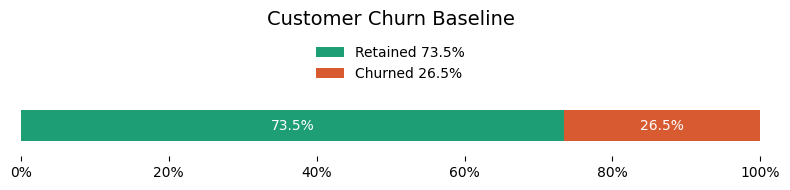

In [7]:
def plot_churn_baseline(df, churn_col='Churn Label', churn_val='Yes'):
    """
    Plots churn baseline as a horizontal bar chart.
    """
    fig, ax = plt.subplots(figsize=(8, 2))

    total = len(df)
    churned = (df[churn_col] == churn_val).sum()
    retained = total - churned
    churn_rate = round(churned / total * 100, 1)
    retention_rate = round(retained / total * 100, 1)

    # Draw the retained bar
    bar_retained = ax.barh(0, retention_rate, color='#1D9E75', height=0.1, label=f'Retained {retention_rate}%')
    # Draw the churned bar, stacked after the retained bar
    bar_churned = ax.barh(0, churn_rate, color='#D85A30', height=0.1, left=retention_rate, label=f'Churned {churn_rate}%')

    # Add churn rate text on each bar
    # For retained bar
    for bar in bar_retained:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f'{retention_rate:.1f}%', va='center', ha='center', color='white', fontsize=10)
    # For churned bar
    for bar in bar_churned:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f'{churn_rate:.1f}%', va='center', ha='center', color='white', fontsize=10)

    ax.set_title('Customer Churn Baseline', fontsize=14)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 100) # Max 100% for stacked bar
    ax.set_ylim(-0.1, 0.3)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks([]) # Remove y-ticks for single bar
    ax.legend(frameon=False, loc='upper center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) # Hide left spine for cleaner look
    ax.spines['bottom'].set_visible(False) # Hide bottom spine
    plt.tight_layout()
    plt.show()

plot_churn_baseline(df, churn_col='Churn Label', churn_val='Yes')

The baseline churn is 26.5%.

### 2.2 Demographic Factors

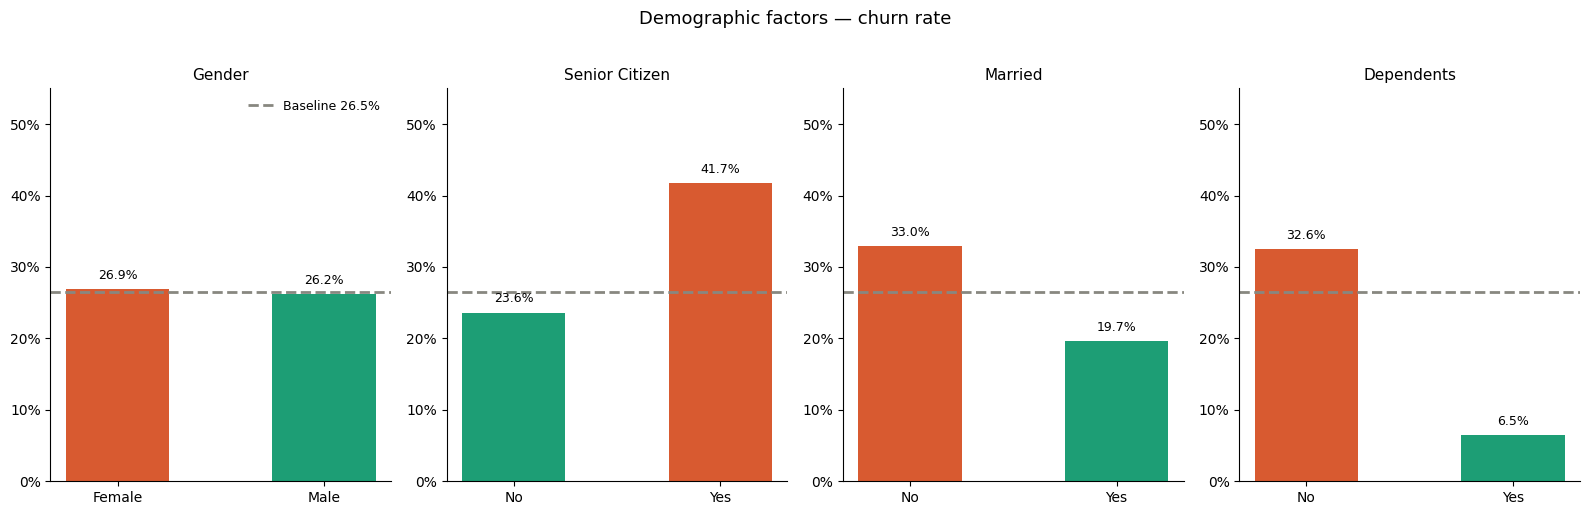

In [8]:
def plot_demographic_factors(df, col, churn_col, churn_val='Yes'):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle('Demographic factors — churn rate', fontsize=13, y=1.02)

    features = col
    titles = col

    for ax, feature, title in zip(axes, features, titles):
        churn_rates = (
            df.groupby(feature)[churn_col]
            .apply(lambda x: (x == churn_val).mean() * 100)
            .reset_index(name='churn_rate')
        )

        bar_colors = [
            '#D85A30' if r > threshold else '#1D9E75'
            for r in churn_rates['churn_rate']
        ]

        bars = ax.bar(churn_rates[feature].astype(str),
               churn_rates['churn_rate'],
               color=bar_colors, width=0.5)

        # Add churn rate text above each bar
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

        # baseline reference line
        ax.axhline(threshold, color='#888780', linewidth=2,
                   linestyle='--', label=f'Baseline {threshold}%')

        ax.set_title(title, fontsize=11)
        ax.set_ylim(0, 55)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis='x', labelsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].legend(fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

# --- Run it ---

threshold = baseline['churn_rate']  # baseline churn rate
demographic_features = ['Gender', 'Senior Citizen', 'Married', 'Dependents']
churn_col='Churn Label'

plot_demographic_factors(df, demographic_features, churn_col=churn_col)

In [9]:
# calculate whether there is a significant different using chi-squared test

demographic_features = ['Gender', 'Senior Citizen', 'Married', 'Dependents']
churn_column = 'Churn Label'

print('Chi-squared test results for demographic factors vs. Churn Label:')
print('----------------------------------------------------------------')

for feature in demographic_features:
    contingency_table = pd.crosstab(df[feature], df[churn_column])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f'\nFeature: {feature}')
    print(f'Chi-squared statistic: {chi2:.2f}')
    print(f'P-value: {p_value:.5f}')

    if p_value < 0.05:
        print('Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).')
    else:
        print('Interpretation: There is no statistically significant association between this feature and customer churn (p >= 0.05).')


Chi-squared test results for demographic factors vs. Churn Label:
----------------------------------------------------------------

Feature: Gender
Chi-squared statistic: 0.48
P-value: 0.48658
Interpretation: There is no statistically significant association between this feature and customer churn (p >= 0.05).

Feature: Senior Citizen
Chi-squared statistic: 159.43
P-value: 0.00000
Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).

Feature: Married
Chi-squared statistic: 158.73
P-value: 0.00000
Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).

Feature: Dependents
Chi-squared statistic: 433.73
P-value: 0.00000
Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).


There are three clear takeaways:

- Gender is essentially irrelevant — a 0.7% gap is negligible and not statistically significant.

- Senior citizens churn at nearly double the rate of non-seniors (41.7% vs 23.6%)

- Customers with partners or dependents churn significantly less, suggesting household stability and financial commitment may reduce churn risk.



### 2.3 Account Factors

Account factors include how a customer paid, the type of contract (month-to-month or by the year).

In [10]:
# check the Tenure Length feature stats
df['Tenure in Months'].describe()

,Tenure in Months
count,7043.000000
mean,32.386767
std,24.542061
min,1.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


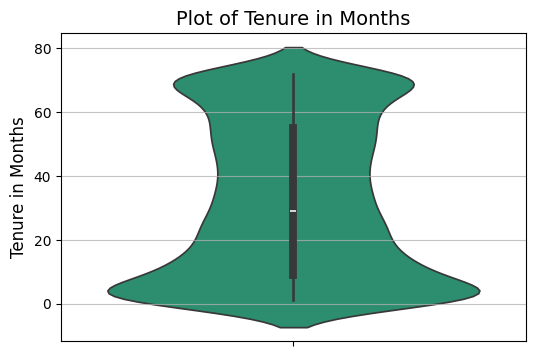

In [11]:
def plot_tenure_months(df, column_name='Tenure in Months'):
    # plot the distribution of length of tenure of each customer in months
    plt.figure(figsize=(6, 4))
    sns.violinplot(y=df[column_name], color='#1D9E75')
    plt.title(f'Plot of {column_name}', fontsize=14)
    plt.ylabel(column_name, fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

plot_tenure_months(df, 'Tenure in Months')

In [12]:
def account_factors(df, churn_col, churn_val='Yes'):
    results = {}

    # categorical factors
    for col in ['Contract', 'Payment Method']:
        results[col] = (
            df.groupby(col)[churn_col]
            .apply(lambda x: round((x == churn_val).mean() * 100, 1))
            .to_dict()
        )

    # tenure by churn status
    results['tenure_avg'] = (
        df.groupby(churn_col)['Tenure in Months']
        .mean()
        .round(1)
        .to_dict()
    )

    # tenure distribution by band
    df['tenure_band'] = pd.cut(
        df['Tenure in Months'],
        bins=[0, 12, 24, 36, 48, 60, 72],
        labels=['0–12mo', '13–24mo', '25–36mo', '37–48mo', '49–60mo', '61–72mo']
    )
    results['tenure_distribution'] = (
        df.groupby(['tenure_band', churn_col], observed=False) # observed=False to suppress FutureWarning
        .size()
        .groupby(level=0)
        .apply(lambda x: round(x / x.sum() * 100, 1))
        .unstack(churn_col)
        .to_dict()
    )

    return results

factors = account_factors(df, "Churn Label")

/tmp/ipykernel_32590/3550752716.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(level=0)


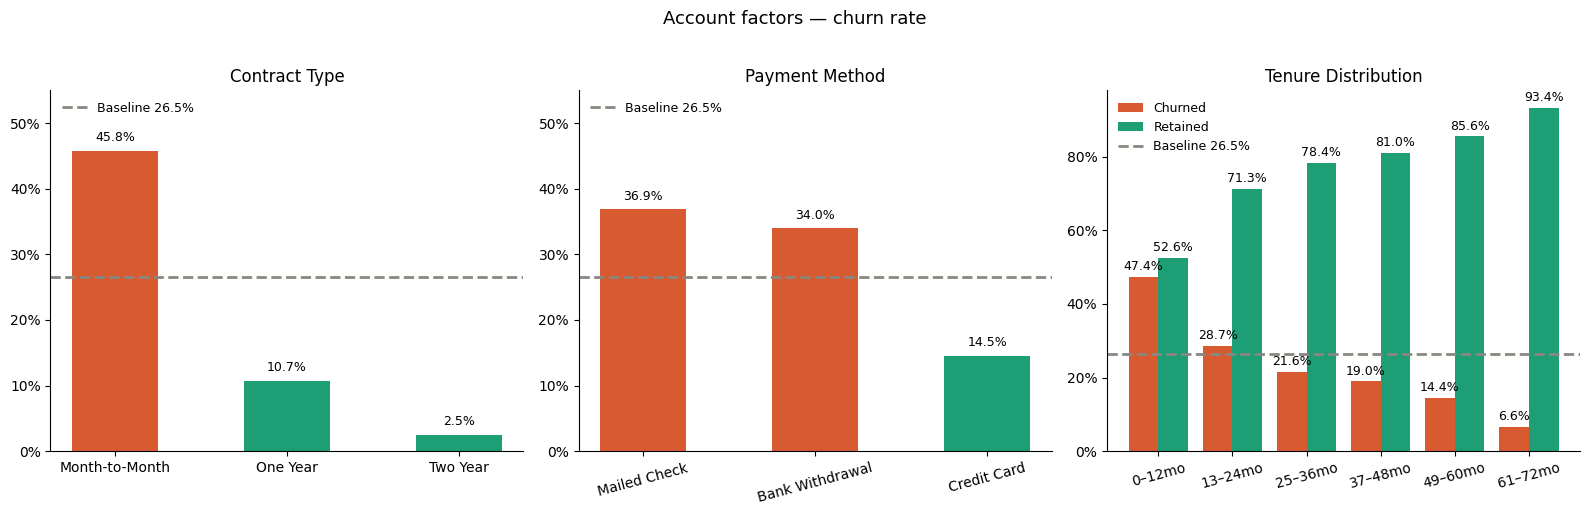

In [13]:
def plot_account_factors(factors):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Account factors \u2014 churn rate', fontsize=13, y=1.02) # subtitle

    # Plot 1 - contract type
    contract = factors['Contract']
    contract_bars = axes[0].bar(contract.keys(), contract.values(),
                color=['#D85A30' if v > threshold else '#1D9E75' for v in contract.values()], # Compare with threshold
                width=0.5)
    axes[0].set_title('Contract Type')
    axes[0].set_ylim(0, 55)

    # Plot 2 - payment method
    payment = dict(sorted(factors['Payment Method'].items(),
                          key=lambda x: x[1], reverse=True))
    payment_bars = axes[1].bar(payment.keys(), payment.values(),
                color=['#D85A30' if v > threshold else '#1D9E75' for v in payment.values()], # Compare with threshold
                width=0.5)
    axes[1].set_title('Payment Method')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].set_ylim(0, 55)

    # Plot 3 - tenure distribution
    tenure_dist = factors['tenure_distribution']
    churned_vals = [tenure_dist['Yes'][b] for b in tenure_dist['Yes']]
    retained_vals = [tenure_dist['No'][b] for b in tenure_dist['No']]

    # Extract the first element from the tuple keys for display
    bands = [b[0] for b in tenure_dist['Yes'].keys()]
    x = range(len(bands))

    # Plotting bars for tenure, these will have their own labels for legend
    bar_churned = axes[2].bar([i - 0.2 for i in x], churned_vals, width=0.4,
                color='#D85A30', label='Churned')
    bar_retained = axes[2].bar([i + 0.2 for i in x], retained_vals, width=0.4,
                color='#1D9E75', label='Retained')
    axes[2].set_xticks(list(x))
    axes[2].set_xticklabels(bands)
    axes[2].set_title('Tenure Distribution')
    axes[2].tick_params(axis='x', rotation=15)

    # Add text labels on top of bars for all plots
    for ax_idx, current_ax in enumerate(axes):
        # For bar plots, use ax.containers
        if ax_idx < 2: # For contract type and payment method
            for bar in current_ax.containers[0]: # Assuming single container for these plots
                yval = bar.get_height()
                current_ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')
        else: # For tenure distribution with two bar containers
            for container in current_ax.containers:
                for bar in container:
                    yval = bar.get_height()
                    current_ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

    # Process each axis for common formatting and legends
    for i, ax in enumerate(axes):
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Draw the baseline WITHOUT a label, add manually to legends
        ax.axhline(threshold, color='#888780', linewidth=2, linestyle='--')

        # Create a Line2D object for the baseline to be used in legends
        baseline_line = mlines.Line2D([], [], color='#888780', linestyle='--', linewidth=2, label=f'Baseline {threshold}%')

        # For the tenure distribution plot (i == 2), combine legends
        if i == 2:
            # Get handles and labels for the 'Churned' and 'Retained' bars
            handles, labels = ax.get_legend_handles_labels()
            # Add the baseline line to the existing handles and labels
            handles.append(baseline_line)
            labels.append(f'Baseline {threshold}%')
            ax.legend(handles=handles, labels=labels, fontsize=9, frameon=False, loc='upper left')
        else:
            # For other plots (contract, payment method), only show the baseline legend
            # We explicitly create a legend with just the baseline_line
            ax.legend(handles=[baseline_line], labels=[f'Baseline {threshold}%'], fontsize=9, frameon=False, loc='upper left')


    plt.tight_layout()
    plt.show()

# --- Run it ---
plot_account_factors(factors)

Here are the key takeaways:

    - Contract Type: Customers on month-to-month contracts have a significantly higher churn rate (42.7%) compared to those with one-year (11.3%) or two-year (2.8%) contracts. This suggests that longer-term contracts help in retaining customers.
    - Payment Method: Customers using Electronic Check as their payment method show the highest churn rate (45.3%). In contrast, other methods like Bank Transfer and Credit Card have much lower churn rates (around 15-17%). This indicates that customers paying via electronic check are more prone to churning.
    - Tenure Distribution: There's a clear trend where churn is much higher among newer customers (e.g., 47.7% churn for 0–12 months tenure). As customer tenure increases, the churn rate significantly drops, showing that long-term customers are much more loyal.


### 2.4 Internet Service and Add-On Factors

The type of internet services offered are DSL or fiber-optic. If an internet service is provided, varoius add-ons are available including online security or file backup services, device protection, tech support, and TV or movie streaming.

In [14]:
# Look at the churn rate for each of the internet service options.
def calculate_internet_service_churn(df, churn_col, churn_val='Yes'):
    results = {}
    internet_features = [
        'Internet Service', 'Online Security', 'Online Backup',
        'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies'
    ]

    for feature in internet_features:
        # Ensure 'No internet service' is handled correctly, it implies 'No' for add-ons
        if feature != 'Internet Service':
            # For add-on services, calculate churn only for customers with internet service
            # And treat 'No internet service' as 'No' for the add-on
            temp_df = df.copy()
            temp_df.loc[temp_df['Internet Service'] == 'No', feature] = 'No'
            churn_rates = temp_df.groupby(feature)[churn_col].apply(lambda x: round((x == churn_val).mean() * 100, 1)).to_dict()
        else:
            # For Internet Service itself, calculate directly
            churn_rates = df.groupby(feature)[churn_col].apply(lambda x: round((x == churn_val).mean() * 100, 1)).to_dict()

        results[feature] = churn_rates

    return results

internet_churn_data = calculate_internet_service_churn(df, churn_col=churn_col)
# print(internet_churn_data)

In [15]:
# Table of internet churn data
pd.DataFrame(internet_churn_data)

,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
No,7.4,31.3,29.2,7.4,7.4,24.3,24.4
Yes,31.8,14.6,21.5,NaN,NaN,30.1,29.9


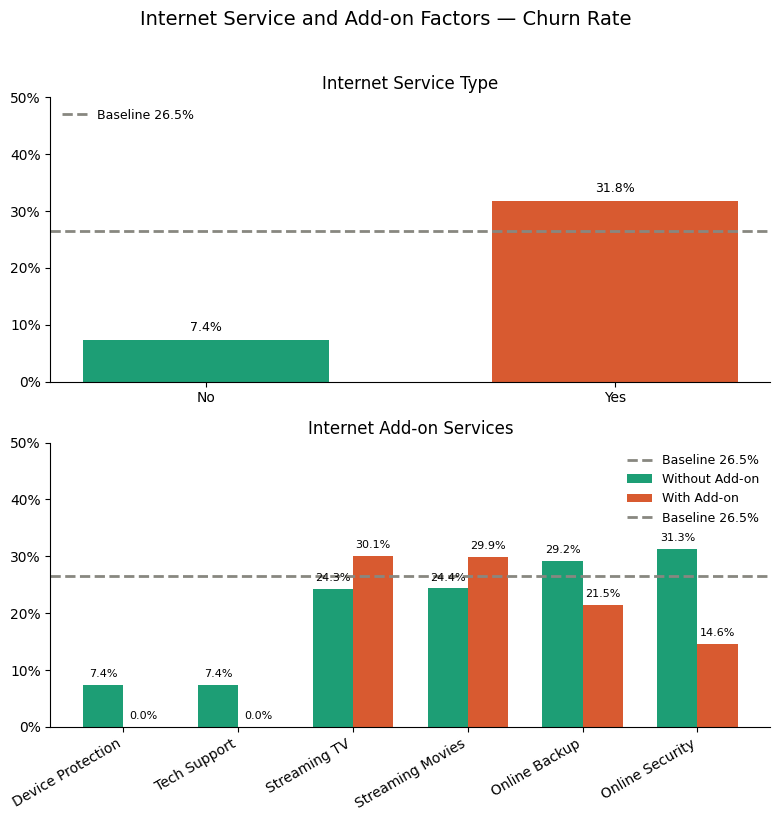

In [16]:
def plot_internet_service_churn(internet_churn_data, baseline_churn_rate):
    fig, axes = plt.subplots(2, 1, figsize=(8, 8))
    fig.suptitle('Internet Service and Add-on Factors — Churn Rate', fontsize=14, y=1.02)

    # --- Plot 1: Internet Service Type ---
    ax1 = axes[0]
    internet_service_data = internet_churn_data['Internet Service']
    service_types = list(internet_service_data.keys())
    churn_rates = list(internet_service_data.values())

    colors = ['#D85A30' if rate > baseline_churn_rate else '#1D9E75' for rate in churn_rates]
    bars1 = ax1.bar(service_types, churn_rates, color=colors, width=0.6)

    ax1.set_title('Internet Service Type', fontsize=12)
    ax1.set_ylim(0, 50)
    ax1.axhline(baseline_churn_rate, color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.tick_params(axis='x', labelsize=10)
    ax1.legend(fontsize=9, frameon=False, loc='upper left')

    # Add percentage labels on bars
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

    # --- Plot 2: Internet Add-on Services ---
    ax2 = axes[1]
    add_on_features_raw = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

    # Prepare data for sorting
    add_on_data_list = []
    for feature in add_on_features_raw:
        churn_no_rate = internet_churn_data[feature].get('No', 0.0)
        churn_yes_rate = internet_churn_data[feature].get('Yes', 0.0)
        add_on_data_list.append((feature, churn_no_rate, churn_yes_rate))

    # Sort by 'No' churn rate in ascending order
    add_on_data_list_sorted = sorted(add_on_data_list, key=lambda x: x[1])

    # Reconstruct lists based on sorted order
    add_on_labels = [item[0] for item in add_on_data_list_sorted]
    churn_no = [item[1] for item in add_on_data_list_sorted]
    churn_yes = [item[2] for item in add_on_data_list_sorted]

    x = range(len(add_on_features_raw))
    width = 0.35

    bars_no = ax2.bar([p - width/2 for p in x], churn_no, width, label='Without Add-on', color='#1D9E75') # Changed color to green
    bars_yes = ax2.bar([p + width/2 for p in x], churn_yes, width, label='With Add-on', color='#D85A30') # Fixed color to orange

    ax2.set_title('Internet Add-on Services', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(add_on_labels, rotation=30, ha='right', fontsize=10)
    ax2.set_ylim(0, 50)
    ax2.axhline(baseline_churn_rate, color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Create a Line2D object for the baseline to be used in legends
    baseline_line = mlines.Line2D([], [], color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')

    # Get handles and labels for the 'No Service' and 'Has Service' bars
    handles, labels = ax2.get_legend_handles_labels()
    # Add the baseline line to the existing handles and labels
    handles.append(baseline_line)
    labels.append(f'Baseline {baseline_churn_rate}%')
    ax2.legend(handles=handles, labels=labels, fontsize=9, frameon=False, loc='upper right')

    # Add percentage labels on bars
    for bars_collection in [bars_no, bars_yes]:
        for bar in bars_collection:
            yval = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=8, color='black')

    plt.tight_layout()
    plt.show()

plot_internet_service_churn(internet_churn_data, threshold)

Key Takeaways:


*   The fiber optic customers churn double the rate of DSL customers.
*   Security and support add-ons have the strongest impact on retaining customers
*   Streaming services have the least impact on retaining customers







### 2.5 Financial Factors

#### 2.5.1 Average Charges

Determine the impact of the amount charged to a customer on churn.

In [17]:
def calculate_average_cost_by_churn(df, churn_col, churn_val='Yes'):
    # Make a copy to avoid modifying the original DataFrame
    df_copy = df.copy()

    # Ensure 'Total Charges' is numeric, coercing errors to NaN
    df_copy['Total Charges'] = pd.to_numeric(df_copy['Total Charges'], errors='coerce')

    # Drop rows where 'Total Charges' is NaN after coercion (these are likely empty strings)
    df_copy.dropna(subset=['Total Charges'], inplace=True)

    # Group by churn status and calculate the mean and standard deviation of monthly and total charges
    avg_costs = df_copy.groupby(churn_col)[['Monthly Charge', 'Total Charges']].agg(['mean', 'std', 'count'])
    return avg_costs


# --- Run it ---

avg_costs_by_churn = calculate_average_cost_by_churn(df, churn_col=churn_col)
print("Average Monthly and Total Charges by Churn Status:")
print(avg_costs_by_churn)

Average Monthly and Total Charges by Churn Status:
            Monthly Charge                  Total Charges                   
                      mean        std count          mean          std count
Churn Label                                                                 
No               61.265124  31.092648  5174   2550.792103  2329.091754  5174
Yes              74.441332  24.666053  1869   1531.796094  1890.822994  1869


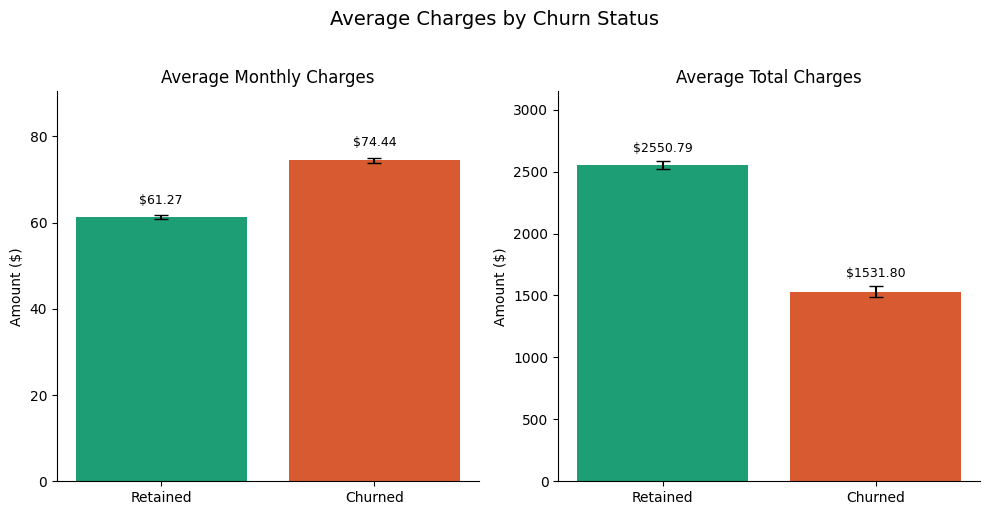

In [18]:
def plot_ave_churn_cost(avg_costs_df):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle('Average Charges by Churn Status', fontsize=14, y=1.02)

    # Plot 1: Average Monthly Charges
    monthly_means = avg_costs_df['Monthly Charge']['mean']
    monthly_stds = avg_costs_df['Monthly Charge']['std']
    monthly_counts = avg_costs_df['Monthly Charge']['count']
    monthly_sems = monthly_stds / (monthly_counts**0.5) # Standard Error of the Mean

    axes[0].bar(monthly_means.index, monthly_means.values, color=['#1D9E75', '#D85A30'],
                yerr=monthly_sems.values, capsize=5, ecolor='black')
    axes[0].set_title('Average Monthly Charges')
    axes[0].set_ylabel('Amount ($)')
    axes[0].set_ylim(0, monthly_means.max() * 1.2 + monthly_sems.max() * 2)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].set_xticks(range(len(monthly_means.index)))
    axes[0].set_xticklabels(['Retained', 'Churned'])
    for i, v in enumerate(monthly_means.values):
        axes[0].text(i, v + monthly_sems.values[i] + 2, f'${v:.2f}', ha='center', va='bottom', fontsize=9, color='black')

    # Plot 2: Average Total Charges
    total_means = avg_costs_df['Total Charges']['mean']
    total_stds = avg_costs_df['Total Charges']['std']
    total_counts = avg_costs_df['Total Charges']['count']
    total_sems = total_stds / (total_counts**0.5) # Standard Error of the Mean

    axes[1].bar(total_means.index, total_means.values, color=['#1D9E75', '#D85A30'],
                yerr=total_sems.values, capsize=5, ecolor='black')
    axes[1].set_title('Average Total Charges')
    axes[1].set_ylabel('Amount ($)')
    axes[1].set_ylim(0, total_means.max() * 1.2 + total_sems.max() * 2)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].set_xticks(range(len(total_means.index)))
    axes[1].set_xticklabels(['Retained', 'Churned'])
    for i, v in enumerate(total_means.values):
        axes[1].text(i, v + total_sems.values[i] + 50, f'${v:.2f}', ha='center', va='bottom', fontsize=9, color='black')

    plt.tight_layout()
    plt.show()


# Call the plotting function with the previously calculated average costs
plot_ave_churn_cost(avg_costs_by_churn)

#### 2.5.2 Churn Rate by Monthly Charges

Determine how the range of monthly charges impact the churn rate.

/tmp/ipykernel_32590/244016992.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Monthly Charges Bins', y='Churn Rate (%)', data=churn_by_monthly_charges, palette=bar_colors, legend=False)


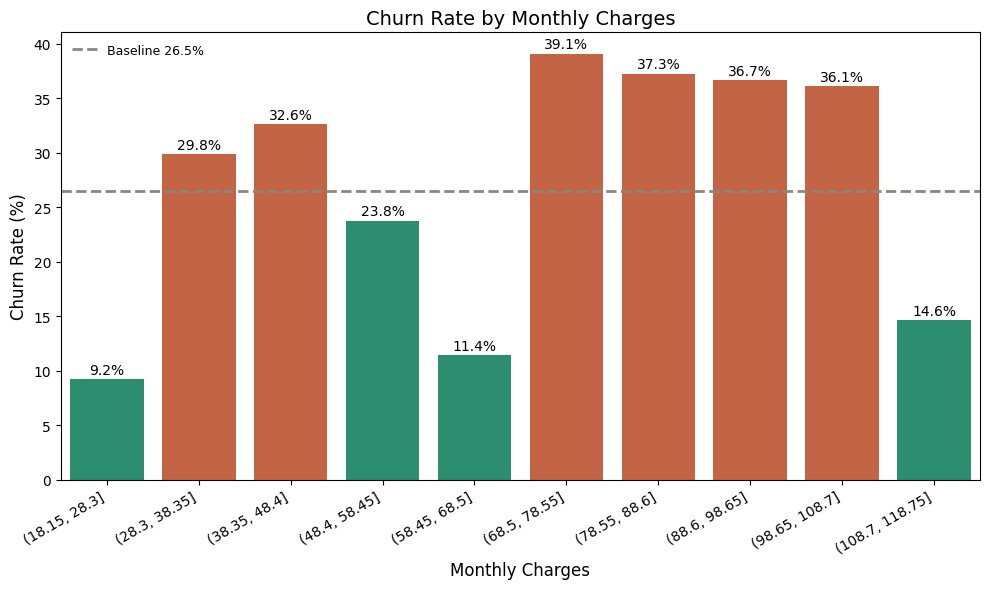

In [19]:
def plot_churn_by_monthly_charges(df, churn_col, bins, precision=2):
    # Create bins for Monthly Charges
    df_copy = df.copy()
    df_copy['Monthly Charges Bins'] = pd.cut(df_copy['Monthly Charge'], bins=bins, precision=precision)

    # Calculate churn rate for each bin
    churn_by_monthly_charges = df_copy.groupby('Monthly Charges Bins', observed=False)[churn_col].mean().reset_index()
    churn_by_monthly_charges['Churn Rate (%)'] = churn_by_monthly_charges[churn_col] * 100

    bar_colors = [
            '#D85A30' if r > threshold else '#1D9E75'
            for r in churn_by_monthly_charges['Churn Rate (%)']
        ]

    # Plotting the churn rate by monthly charges bins
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Monthly Charges Bins', y='Churn Rate (%)', data=churn_by_monthly_charges, palette=bar_colors, legend=False)

    plt.title('Churn Rate by Monthly Charges', fontsize=14)
    plt.xlabel('Monthly Charges', fontsize=12)
    plt.ylabel('Churn Rate (%)', fontsize=12)
    plt.xticks(rotation=30, ha='right')

    # Remove horizontal grid lines
    ax.grid(False, axis='y')

    # Add baseline threshold line
    baseline_churn_rate = baseline['churn_rate'] # Access the baseline from the global scope
    ax.axhline(baseline_churn_rate, color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')
    ax.legend(fontsize=9, frameon=False, loc='upper left')

    # Add percentage labels on top of bars
    for index, row in churn_by_monthly_charges.iterrows():
        plt.text(index, row['Churn Rate (%)'] + 0.5, f"{row['Churn Rate (%)']:.1f}%", color='black', ha="center")

    plt.tight_layout()
    plt.show()

# --- Run it ---
plot_churn_by_monthly_charges(df, churn_col='Churn Value', bins=10)

Key Takeaway:
- Customers that churn tend to pay a higher average monthly charge
- Customers that are charged over approximately $70 are more likely to churn.
- Customers that churn have a lower total charge on average. This is likely due to having a higher monthly charge, resulting in them leaving.

### 2.6 Multivariate Analysis

Multiple characteristic can be combined to identify high-risk customers.

The factor identified to be the strongest predictor of churn through single-factor analysis is the month-to-month contract type. Within each contract type, determine how churn rate vary when data is sliced by other factors with a higher-than-baseline churn rate.


In [20]:
def _add_tenure_band(df):
    """Creates tenure_band column if not already present."""
    if 'tenure_band' not in df.columns:
        df['tenure_band'] = pd.cut(
            df['Tenure in Months'],
            bins=[0, 12, 24, 36, 48, 60, 72],
            labels=['0–12mo', '13–24mo', '25–36mo', '37–48mo', '49–60mo', '61–72mo']
        )
    return df

def build_contract_pivots(df, anchor='Contract', factors=None,
                          churn_col='Churn Label', churn_val='Yes'):
    """
    Builds churn rate pivot tables for anchor × each factor.

    Parameters
    ----------
    df       : source dataframe
    anchor   : the column to anchor every pivot on (default: 'Contract')
    factors  : list of columns to cross against the anchor — REQUIRED
    churn_col: column containing churn labels
    churn_val: value that represents a churned customer
    """
    if factors is None:
        raise ValueError(
            "No factors provided. Please pass a list of column names to cross "
            "against the anchor. Example:\n\n"
            "    build_contract_pivots(df, factors=['Internet Service', "
            "'tenure_band', 'Payment Method', 'Online Security', 'Senior Citizen'])"
        )

    df = _add_tenure_band(df.copy())

    def _churn_pivot(group_cols, unstack_col):
        return (
            df.groupby(group_cols, observed=True)[churn_col]
            .apply(lambda x: round((x == churn_val).mean() * 100, 1))
            .unstack(unstack_col)
        )

    pivots = {}
    for factor in factors:
        title = f'{anchor} × {factor}'
        pivots[title] = _churn_pivot([anchor, factor], factor)

    return pivots


def display_contract_pivots(pivots, anchor, anchor_val, threshold):
    """
    Prints each pivot table, flagging the anchor row and cells above baseline.

    Parameters
    ----------
    pivots  : dict returned by build_contract_pivots
    anchor  : the anchor contract value to highlight
    threshold: churn rate threshold to flag high-risk cells
    """

    for title, table in pivots.items():
        print(f"\n{'═' * 55}")
        print(f"  {title}")
        print(f"  Baseline churn rate: {threshold}%  |  ▲ = above baseline threshold")
        print(f"{'═' * 55}")

        cols = list(table.columns)
        col_width = 14
        header = f"{anchor:<22}" + "".join(f"{c:>{col_width}}" for c in cols)
        print(header)
        print("-" * len(header))

        for contract, row in table.iterrows():
            prefix = "▶ " if contract == anchor_val else "  "
            row_str = f"{prefix}{contract:<20}"
            for val in row:
                if pd.isna(val):
                    cell = "—"
                else:
                    flag = " ▲" if val > threshold else " "
                    cell = f"{val}%{flag}"
                row_str += f"{cell:>{col_width}}"
            print(row_str)
        print()


# --- Run it with anchor value inputs ---
anchor = 'Contract'
anchor_val = 'Month-to-Month'

factors = [
    'Internet Service', 'tenure_band',
    'Payment Method', 'Online Security', 'Senior Citizen'
]

pivots = build_contract_pivots(df, anchor=anchor, factors=factors)
display_contract_pivots(pivots, anchor=anchor, anchor_val=anchor_val, threshold=threshold)


═══════════════════════════════════════════════════════
  Contract × Internet Service
  Baseline churn rate: 26.5%  |  ▲ = above baseline threshold
═══════════════════════════════════════════════════════
Contract                          No           Yes
--------------------------------------------------
▶ Month-to-Month              19.1%        50.3% ▲
  One Year                     2.5%         13.3% 
  Two Year                     0.8%          3.5% 


═══════════════════════════════════════════════════════
  Contract × tenure_band
  Baseline churn rate: 26.5%  |  ▲ = above baseline threshold
═══════════════════════════════════════════════════════
Contract                      0–12mo       13–24mo       25–36mo       37–48mo       49–60mo       61–72mo
----------------------------------------------------------------------------------------------------------
▶ Month-to-Month             53.5% ▲       40.5% ▲       36.5% ▲       37.6% ▲       31.1% ▲       27.6% ▲
  One Year        

In [21]:
# Rank the combinations of Contract Type with other individual factors

def rank_anchor_combinations(pivots, threshold, anchor_val):
    """
    Extracts the anchor row from each pivot table and ranks all
    factor levels by churn rate, highest to lowest.

    Parameters
    ----------
    pivots     : dict returned by build_contract_pivots
    anchor_val : the contract type row to extract
    threshold   : churn rate threshold to flag high-risk combinations
    """
    records = []

    for title, table in pivots.items():
        if anchor_val not in table.index:
            print(f"  Warning: '{anchor_val}' not found in {title}, skipping.")
            continue

        factor_name = title.split(' × ')[1]
        row = table.loc[anchor_val]

        for level, churn_rate in row.items():
            if pd.isna(churn_rate):
                continue
            records.append({
                'Factor': factor_name,
                'Level': str(level),
                'Churn Rate': churn_rate,
                'Above Baseline threshold': churn_rate > threshold
            })

    ranking = (
        pd.DataFrame(records)
        .sort_values('Churn Rate', ascending=False)
        .reset_index(drop=True)
    )
    ranking.index += 1  # Start ranking at 1
    return ranking


# --- Run it ---
ranking = rank_anchor_combinations(pivots, threshold, anchor_val)
print(ranking.to_string())

              Factor            Level  Churn Rate  Above Baseline threshold
1     Senior Citizen              Yes        81.4                      True
2     Payment Method     Mailed Check        55.6                      True
3        tenure_band           0–12mo        53.5                      True
4     Payment Method  Bank Withdrawal        53.3                      True
5   Internet Service              Yes        50.3                      True
6    Online Security               No        48.9                      True
7        tenure_band          13–24mo        40.5                      True
8     Senior Citizen               No        39.6                      True
9        tenure_band          37–48mo        37.6                      True
10       tenure_band          25–36mo        36.5                      True
11   Online Security              Yes        32.2                      True
12       tenure_band          49–60mo        31.1                      True
13    Paymen

In [22]:
# Pull out factor pairs from rankings

def create_factor_pairs_list(ranking, select_n):
  ''' Extract the top n (factor, level) pairs from rankings as a tuple.'''
  factor_pairs_list = []
  for i in range(select_n):
    get_pairs = tuple(ranking.iloc[i][['Factor', 'Level']])
    factor_pairs_list.append(get_pairs)
  return factor_pairs_list

factor_pairs = create_factor_pairs_list(ranking, select_n=3)

In [23]:
# Get the next top three factors

def extract_third_factors(ranking, factor_pairs):
    """
    Extracts third factors from the ranking table by removing
    factors already present in factor_pairs.

    Parameters
    ----------
    ranking      : dataframe returned by rank_anchor_combinations
    factor_pairs : list of (factor, level) tuples returned by
                   extract_factor_pairs
    """
    if not factor_pairs:
        raise ValueError(
            "factor_pairs is empty. Please run extract_factor_pairs first. "
            "Example:\n\n"
            "    factor_pairs = extract_factor_pairs(ranking, top_n=3)\n"
            "    third_factors = extract_third_factors(ranking, factor_pairs)"
        )

    # get factors already used in pairs
    used_factors = {factor for factor, _ in factor_pairs}

    # get all unique factors in ranking
    all_factors = set(ranking['Factor'].unique())

    # remove used factors
    remaining = all_factors - used_factors

    # Step 5 — return as sorted list for consistency
    third_factors = sorted(remaining)

    print(f"Used factors (excluded): {sorted(used_factors)}")
    print(f"Extracted third factor(s): {third_factors}")

    return third_factors

third_factors = extract_third_factors(ranking, factor_pairs)

Used factors (excluded): ['Payment Method', 'Senior Citizen', 'tenure_band']
Extracted third factor(s): ['Internet Service', 'Online Security']


In [24]:
# Add a third factor to the above pivot table

def build_threeway_pivots(df, anchor_col, anchor_val,
                          factor_pairs=None, third_factors=None, threshold=threshold,
                          churn_col='Churn Label', churn_val='Yes'):
    """
    Filters to anchor segment, then builds churn rate tables for
    factor_pair × third_factor combinations.

    Parameters
    ----------
    df            : source dataframe
    anchor_col    : column used to filter to the anchor segment
    anchor_val    : value to filter on (default: 'Month-to-month')
    factor_pairs  : list of (factor, level) tuples to filter on — REQUIRED
    third_factors : list of columns to cross against each pair — REQUIRED
    churn_col     : column containing churn labels
    churn_val     : value that represents a churned customer
    threshold     : churn rate threshold to flag high-risk combinations
    """
    if factor_pairs is None:
        raise ValueError(
            "No factor pairs provided. Please pass a list of (factor, level) tuples. "
            "Example:\n\n"
            "    factor_pairs=[('Internet Service', 'Fiber optic'), "
            "('tenure_band', '0–12mo')]"
        )
    if third_factors is None:
        raise ValueError(
            "No third factors provided. Please pass a list of column names. "
            "Example:\n\n"
            "    third_factors=['Payment Method', 'Online Security', 'Senior Citizen']"
        )

    df = df.copy()

    # Ensure tenure_band is consistently created
    df = _add_tenure_band(df)

    # Filter to anchor segment
    anchor_df = df[df[anchor_col] == anchor_val].copy()

    results = {}
    for factor, level in factor_pairs:
        pair_df = anchor_df[anchor_df[factor] == level]
        pair_label = f"{anchor_val} + {str(level)}"

        for third in third_factors:
            if third == factor:
                continue  # skip self-cross

            title = f"{pair_label} × {third}"
            table = (
                pair_df.groupby(third, observed=True)[churn_col]
                .apply(lambda x: round((x == churn_val).mean() * 100, 1))
                .rename('Churn Rate')
                .to_frame()
            )
            table['Count'] = pair_df.groupby(third, observed=True).size()
            table['Above Baseline'] = table['Churn Rate'] > threshold
            results[title] = table.sort_values('Churn Rate', ascending=False)

    return results


def display_threeway_pivots(results):
    """
    Prints each three-way churn rate table.
    """
    for title, table in results.items():
        print(f"\n{'═' * 55}")
        print(f"  {title}")
        print(f"{'═' * 55}")
        print(table.to_string())
        print()


# --- Run it ---
threeway_results = build_threeway_pivots(df, anchor_col=anchor, anchor_val=anchor_val,
                                         factor_pairs=factor_pairs, third_factors=third_factors)
display_threeway_pivots(threeway_results)


═══════════════════════════════════════════════════════
  Month-to-Month + Yes × Internet Service
═══════════════════════════════════════════════════════
                  Churn Rate  Count  Above Baseline
Internet Service                                   
No                      83.3      6            True
Yes                     81.3    536            True


═══════════════════════════════════════════════════════
  Month-to-Month + Yes × Online Security
═══════════════════════════════════════════════════════
                 Churn Rate  Count  Above Baseline
Online Security                                   
No                     83.5    467            True
Yes                    68.0     75            True


═══════════════════════════════════════════════════════
  Month-to-Month + Mailed Check × Internet Service
═══════════════════════════════════════════════════════
                  Churn Rate  Count  Above Baseline
Internet Service                                   
Yes      

In [25]:
def extract_profiles(df, threeway, anchor_col='Contract',
                     anchor_val='Month-to-Month', top_n=1, factor_pairs_list=None):
    """
    Extracts risk profiles from the three-way pivot results by
    selecting the top-churning third factor level for each pair.

    Parameters
    ----------
    df         : source dataframe
    threeway   : dict returned by build_threeway_pivots
    anchor_col : column used to filter to the anchor segment
    anchor_val : anchor value (default: 'Month-to-Month')
    top_n      : number of third factor levels to extract per table
    factor_pairs_list : list of (factor, level) tuples for accurate mapping
    """
    if not threeway:
        raise ValueError(
            "threeway is empty. Please run build_threeway_pivots first. "
            "Example:\n\n"
            "    threeway = build_threeway_pivots(df, factor_pairs=factor_pairs,\n"
            "                                    third_factors=third_factors)\n"
            "    profiles = extract_profiles(df, threeway)"
        )
    if factor_pairs_list is None:
        raise ValueError(
            "factor_pairs_list is required for accurate profile extraction. "
            "Please pass the list of (factor, level) tuples."
        )

    df = _add_tenure_band(df.copy())
    profiles = {}

    for title, table in threeway.items():
        # Step 2 — parse title to recover factor pair and third factor
        # title format: "{anchor_val} + {level} × {third_factor}"
        left, third_factor = title.split(' × ')
        pair_display_level = left.replace(f"{anchor_val} + ", "").strip()

        # Resolve original_factor and original_level using factor_pairs_list
        original_factor = None
        original_level = None
        for f, l in factor_pairs_list:
            if str(l) == pair_display_level:
                original_factor = f
                original_level = l
                break

        if original_factor is None:
            print(f"  Warning: could not resolve original factor for '{pair_display_level}', skipping.")
            continue

        pair_col = original_factor
        pair_level = original_level

        # Step 2 — top N third factor levels by churn rate
        top_levels = table.head(top_n)

        for third_level, row in top_levels.iterrows():
            # Step 3 — construct boolean mask
            mask = (
                (df[anchor_col] == anchor_val) &
                (df[pair_col].astype(str) == str(pair_level)) &
                (df[third_factor].astype(str) == str(third_level))
            )

            # Step 4 — assemble label to include original factor name
            label = f"{anchor_val} + {original_factor} {original_level} + {third_factor} {third_level}"

            profiles[label] = mask
            print(f"  Profile extracted: '{label}' "
                  f"(Churn Rate: {row['Churn Rate']}%)")

    return profiles

def build_risk_profiles(df, profiles=None, churn_col='Churn Label', churn_val='Yes'):
    """
    Calculates churn rate and count for each named risk profile.

    Parameters
    ----------
    df       : source dataframe
    profiles : dict of {profile_name: boolean mask} — REQUIRED
    churn_col: column containing churn labels
    churn_val: value that represents a churned customer
    """
    if profiles is None:
        raise ValueError(
            "No profiles provided. Please pass a dict of named boolean masks. "
            "Example:\n\n"
            "    profiles={\n"
            "        'M2M + Fiber + 0–12mo': (\n"
            "            (df['Contract'] == 'Month-to-month') &\n"
            "            (df['Internet Service'] == 'Fiber optic') &\n"
            "            (df['tenure_band'] == '0–12mo')\n"
            "        )\n"
            "    }"
        )

    df = df.copy()

    # Ensure tenure_band is consistently created
    df = _add_tenure_band(df)

    records = []
    for label, mask in profiles.items():
        subset = df[mask]
        churn_rate = round((subset[churn_col] == churn_val).mean() * 100, 1)
        records.append({
            'Profile': label,
            'Count': len(subset),
            'Churn Rate': churn_rate,
            'Above Baseline Threshold': churn_rate > threshold
        })

    return (
        pd.DataFrame(records)
        .set_index('Profile')
        .sort_values('Churn Rate', ascending=False)
    )


# --- Run it ---

profiles = extract_profiles(df, threeway_results, anchor_col=anchor, anchor_val=anchor_val, factor_pairs_list=factor_pairs)
risk_profiles = build_risk_profiles(df, profiles=profiles, churn_col=churn_col)

  Profile extracted: 'Month-to-Month + Senior Citizen Yes + Internet Service No' (Churn Rate: 83.3%)
  Profile extracted: 'Month-to-Month + Senior Citizen Yes + Online Security No' (Churn Rate: 83.5%)
  Profile extracted: 'Month-to-Month + Payment Method Mailed Check + Internet Service Yes' (Churn Rate: 61.4%)
  Profile extracted: 'Month-to-Month + Payment Method Mailed Check + Online Security No' (Churn Rate: 57.9%)
  Profile extracted: 'Month-to-Month + tenure_band 0–12mo + Internet Service Yes' (Churn Rate: 61.2%)
  Profile extracted: 'Month-to-Month + tenure_band 0–12mo + Online Security No' (Churn Rate: 55.3%)


/tmp/ipykernel_32590/3671428909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn Rate', y=risk_profiles.index,


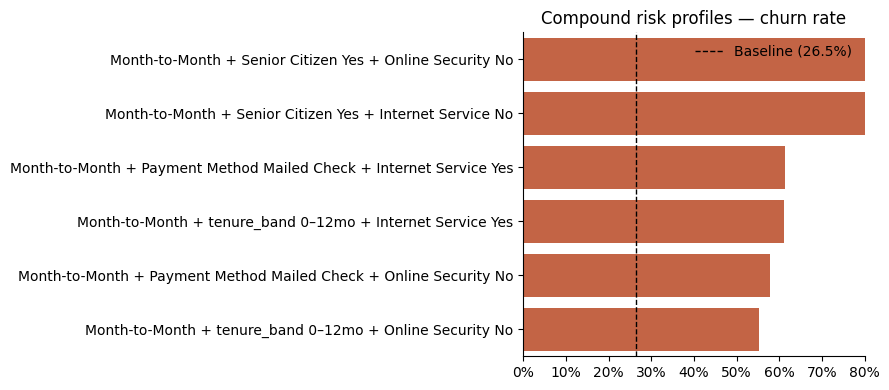

In [26]:
def plot_risk_profiles(risk_profiles, threshold=threshold):
    """
    Plots compound risk profiles as a horizontal bar chart.
    """
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#D85A30' if r > threshold else '#1D9E75'
              for r in risk_profiles['Churn Rate']]

    sns.barplot(x='Churn Rate', y=risk_profiles.index,
                data=risk_profiles.reset_index(),
                palette=colors, ax=ax)

    ax.axvline(threshold, color='black', linestyle='--',
               linewidth=1, label=f'Baseline ({threshold}%)')
    ax.set_title('Compound risk profiles — churn rate')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 80)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_risk_profiles(risk_profiles, threshold=threshold)

The profiles most likely to churn are the customers with month-to-month contracts who have been with the company for less than one year, a senior citizen, or paying by mailed check.